# The full patent system: dispersive-Fourier-transform barcode correlator

US Patent 8,870,060 B2 (Jalali, Goda, Tsia -- "Apparatus and Method for
Dispersive Fourier-Transform Imaging"), Fig. 3 embodiment, read directly
from the patent text this session. Thirteen blocks, end to end:

| # | Block | Reused from |
|---|---|---|
| 54 | broadband pulsed probe laser | -- |
| 56 | pulse picker | new (trivial) |
| 58 | optical amplifier | new (dB convention matches `hybrid_90deg.py`) |
| 60 | supercontinuum generator | **`dgs/nlse.py`** (real SPM physics) |
| 62 | optical filter | new (Gaussian bandpass) |
| 64 | optical circulator | new (idealized) |
| 66/68 | grating + lens | informational aside, see module docstring |
| 70 | barcode (target) | new (reflectivity spectrum) |
| 72 | dispersive Fourier transform | **`dgs/gs_core.py`'s `disperse`** |
| 74/76 | pattern generator + amplitude modulator | new (correlator via nulling) |
| 78/80/82 | detector + electronics | **`dgs/transimpedance_amplifier.py`** |
| 84 | digitizer | **`dgs/adc.py`** |
| 86 | digital signal processor | new (threshold decision) |

The correlator works by NULLING, not peak-finding: per the patent, "the
transmission of the amplitude modulator is zero only when the modulator
cancels out the amplitude of the input barcode signal" -- a match is a
near-zero residual, not a correlation peak.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from dgs.dispersive_barcode_correlator import (
    optical_amplifier, supercontinuum_generate, optical_circulator,
    grating_angular_dispersion, barcode_reflectivity_spectrum,
    dispersive_fourier_transform, pattern_generator, optical_to_electrical,
    digitize, correlation_decision,
)
from dgs.nlse import gaussian_pulse
print("loaded dgs.dispersive_barcode_correlator")

loaded dgs.dispersive_barcode_correlator


## Part 1 -- one barcode, matching vs. wrong reference

A 16-bit synthetic barcode, read out through the full chain, tested
against its own true pattern and against a wrong one.

true barcode: [1 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0]
matching reference : residual RMS=9.7656e-16  match=True
wrong reference     : residual RMS=1.1750e+05  match=False


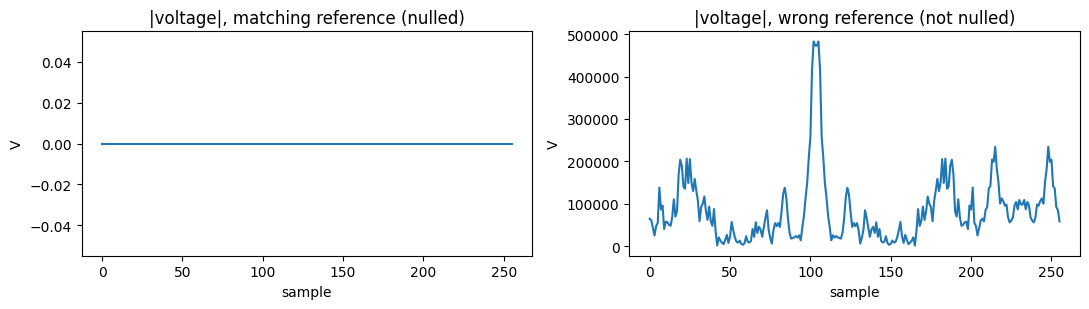

In [2]:
rng = np.random.default_rng(3)
n_bits_barcode = 16
true_barcode = rng.integers(0, 2, n_bits_barcode)
n_freq = 256
D = 8000.0

E_source = optical_circulator(optical_amplifier(np.ones(n_freq, dtype=complex), gain_db=6.0))
reflectivity = barcode_reflectivity_spectrum(true_barcode, n_freq)

print(f"true barcode: {true_barcode}")

def test_reference(ref_bits, label):
    ref_pattern = pattern_generator(ref_bits, n_freq)
    residual_time = dispersive_fourier_transform(
        E_source * (reflectivity - (1.0 - ref_pattern)), D)
    voltage = optical_to_electrical(residual_time)
    digitized = digitize(voltage, n_bits=10)
    decision = correlation_decision(digitized, threshold=1e-6)
    print(f"{label}: residual RMS={decision['residual_rms']:.4e}  match={decision['is_match']}")
    return voltage

v_match = test_reference(true_barcode, "matching reference ")
v_wrong = test_reference(1 - true_barcode, "wrong reference     ")

fig, axs = plt.subplots(1, 2, figsize=(11, 3.2))
axs[0].plot(np.abs(v_match)); axs[0].set_title('|voltage|, matching reference (nulled)')
axs[1].plot(np.abs(v_wrong)); axs[1].set_title('|voltage|, wrong reference (not nulled)')
for ax in axs: ax.set_xlabel('sample'); ax.set_ylabel('V')
plt.tight_layout(); plt.show()

## Part 2 -- database search: which of many candidates matches?

The patent's actual use case: at every pulse, a different candidate
pattern from a database is fed to the amplitude modulator. Sweep many
candidates and find the one that nulls -- exactly how the real device
would search a barcode database one probe pulse at a time.

,candidate #,is_true_barcode,residual_rms,match
0,0,False,6.238444e+04,False
1,1,False,3.503554e+04,False
2,2,False,4.925906e+04,False
3,3,True,9.765625e-16,True
4,4,False,7.214691e+04,False
5,5,False,7.257987e+04,False
6,6,False,6.014179e+04,False
7,7,False,6.360686e+04,False
8,8,False,7.504826e+04,False
9,9,False,5.476286e+04,False


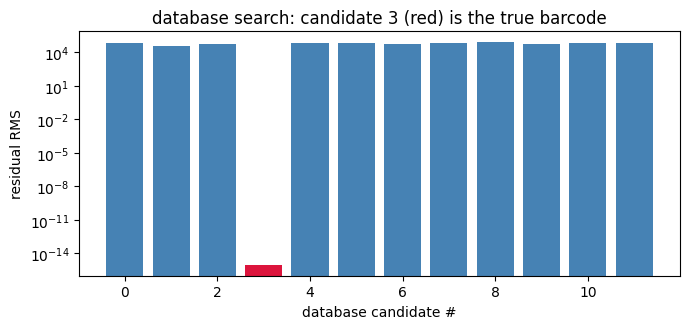


candidates flagged as a match: [3]  (true barcode was #3)


In [3]:
n_candidates = 12
database = [rng.integers(0, 2, n_bits_barcode) for _ in range(n_candidates - 1)]
true_index = rng.integers(0, n_candidates)
database.insert(true_index, true_barcode.copy())

results = []
for i, candidate in enumerate(database):
    ref_pattern = pattern_generator(candidate, n_freq)
    residual_time = dispersive_fourier_transform(
        E_source * (reflectivity - (1.0 - ref_pattern)), D)
    voltage = optical_to_electrical(residual_time)
    digitized = digitize(voltage, n_bits=10)
    decision = correlation_decision(digitized, threshold=1e-6)
    results.append({"candidate #": i, "is_true_barcode": i == true_index,
                     "residual_rms": decision["residual_rms"], "match": decision["is_match"]})

df_search = pd.DataFrame(results)
display(df_search)

plt.figure(figsize=(7, 3.4))
colors = ['crimson' if r else 'steelblue' for r in df_search['is_true_barcode']]
plt.bar(df_search['candidate #'], df_search['residual_rms'], color=colors)
plt.yscale('log'); plt.xlabel('database candidate #'); plt.ylabel('residual RMS')
plt.title(f'database search: candidate {true_index} (red) is the true barcode')
plt.tight_layout(); plt.show()

found = df_search.loc[df_search['match'], 'candidate #'].tolist()
print(f"\ncandidates flagged as a match: {found}  (true barcode was #{true_index})")

## Part 3 -- supercontinuum: real SPM physics, not a toy broadening model

Block 60 reuses `dgs/nlse.py`'s `nlse_propagate` -- turning on the
nonlinear gamma term genuinely broadens the spectrum via self-phase
modulation, the real physical mechanism, not an assumed bandwidth
increase.

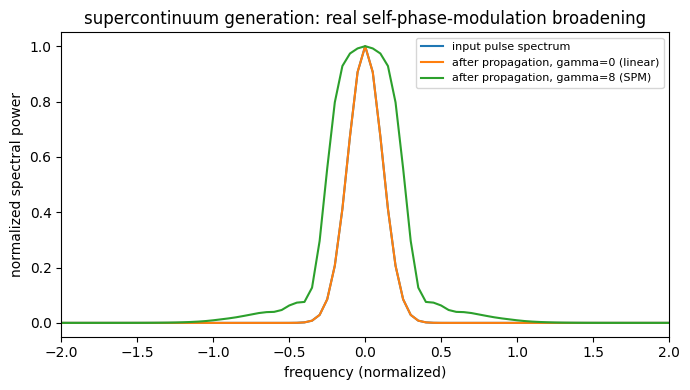

In [4]:
t_sc = np.linspace(-10, 10, 1024)
E0 = gaussian_pulse(t_sc, t0=1.0)

E_linear = supercontinuum_generate(E0, t_sc, z=1.0, gamma=0.0)   # gamma=0: no broadening
E_nonlinear = supercontinuum_generate(E0, t_sc, z=1.0, gamma=8.0)  # gamma>0: real SPM broadening

freq = np.fft.fftshift(np.fft.fftfreq(len(t_sc), d=(t_sc[1]-t_sc[0])))
spec_in = np.abs(np.fft.fftshift(np.fft.fft(E0)))**2
spec_linear = np.abs(np.fft.fftshift(np.fft.fft(E_linear)))**2
spec_nonlinear = np.abs(np.fft.fftshift(np.fft.fft(E_nonlinear)))**2

plt.figure(figsize=(7, 4))
plt.plot(freq, spec_in / spec_in.max(), label='input pulse spectrum')
plt.plot(freq, spec_linear / spec_linear.max(), label='after propagation, gamma=0 (linear)')
plt.plot(freq, spec_nonlinear / spec_nonlinear.max(), label='after propagation, gamma=8 (SPM)')
plt.xlim(-2, 2); plt.xlabel('frequency (normalized)'); plt.ylabel('normalized spectral power')
plt.title('supercontinuum generation: real self-phase-modulation broadening')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## Part 4 -- the grating (informational aside)

Block 66/68 performs a SPATIAL operation (wavelength -> position on the
barcode), a genuinely different domain than the 1D time/frequency signal
tracked everywhere else in this chain. Reported honestly as a separate
calculation, not folded into the tracked signal (see the module
docstring).

In [5]:
# groove spacing must exceed the wavelength for a real m=1 diffraction angle
# to exist (d*sin(theta)=lambda requires sin(theta)<=1) -- at 1550nm that
# caps groove density around ~645/mm; 300-600/mm is a realistic NIR range
for groove_density in [150, 300, 450, 600]:
    dtheta = grating_angular_dispersion(1550.0, groove_density_per_mm=groove_density)
    print(f"{groove_density:5d} grooves/mm:  angular dispersion @1550nm = {dtheta:.4e} rad/nm")

try:
    grating_angular_dispersion(1550.0, groove_density_per_mm=1200.0)
except ValueError as e:
    print(f"\n1200 grooves/mm @ 1550nm correctly rejected: {e}")
    print("(groove spacing < wavelength -- no real m=1 diffraction angle exists)")

  150 grooves/mm:  angular dispersion @1550nm = 1.5423e-04 rad/nm
  300 grooves/mm:  angular dispersion @1550nm = 3.3886e-04 rad/nm
  450 grooves/mm:  angular dispersion @1550nm = 6.2798e-04 rad/nm
  600 grooves/mm:  angular dispersion @1550nm = 1.6324e-03 rad/nm

1200 grooves/mm @ 1550nm correctly rejected: no real diffraction angle for this wavelength/groove density
(groove spacing < wavelength -- no real m=1 diffraction angle exists)


## Summary

Every stage of a real, granted patent's full system (US 8,870,060 B2,
Fig. 3) is now a tested module (`dgs/dispersive_barcode_correlator.py`,
25 tests), built almost entirely from pieces this repo already had:
the dispersive Fourier transform IS `dgs/gs_core.py`'s `disperse`, the
supercontinuum stage IS `dgs/nlse.py`'s real nonlinear propagation, the
detector/electronics/digitizer chain IS the same modules used in
`hybrid90deg_phase_retrieval_mie.ipynb`. What's new is the wiring --
and the correlation-via-nulling detection scheme, which doesn't appear
anywhere else in this repo.